## Truncated SVD versus DLR-PCG

This notebook tests out the similarity of using the rank-$r$ truncated SVD solution of $X = U_x \Sigma_x V_x^T$ versus obtaining it via the DLR-PCG scheme.

---

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import Function, FunctionSpace, plot
from algorithms.dynamical_low_rank_pcg import DynamicalLowRankPCG
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W, tikhonov_solver

from utils.colors import C2, C3, C5, CMAP
from utils.problem_setup import TestProblemsSetup
from utils.metrics import matrix_to_vec, vec_to_matrix, SpaceIndexing
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit

SEED = 15

In [7]:
setup = TestProblemsSetup(n=48)
problems = setup.get_test_problems(compute_weights=True)
problem_params = setup.problem_params

In [8]:
def plot_solutions(f_list, params, titles=None, figsize=(10, 3), nrows=None, ncols=None, cbar=True):
    width = params['width']
    height = params['height']
    x0s, y0s = params['x0'], params['y0']

    import matplotlib.patches as patches
    
    if titles is None:
        titles = ['' for _ in f_list]

    if nrows is None:
        nrows = 1

    if ncols is None:
        ncols = len(f_list)
        
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)

    if (ncols + nrows) > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for ax, fi, ti in zip(axes, f_list, titles):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP) #, norm=norm)

        ax.set_title(ti)
        ax.set_xticks([])
        ax.set_yticks([])
        
        if cbar:
            fig.colorbar(p, ax=ax, format="%.2f", shrink=0.655)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    plt.show()

In [9]:
pid = 'II'
p = problems[pid]
params = problem_params[pid]

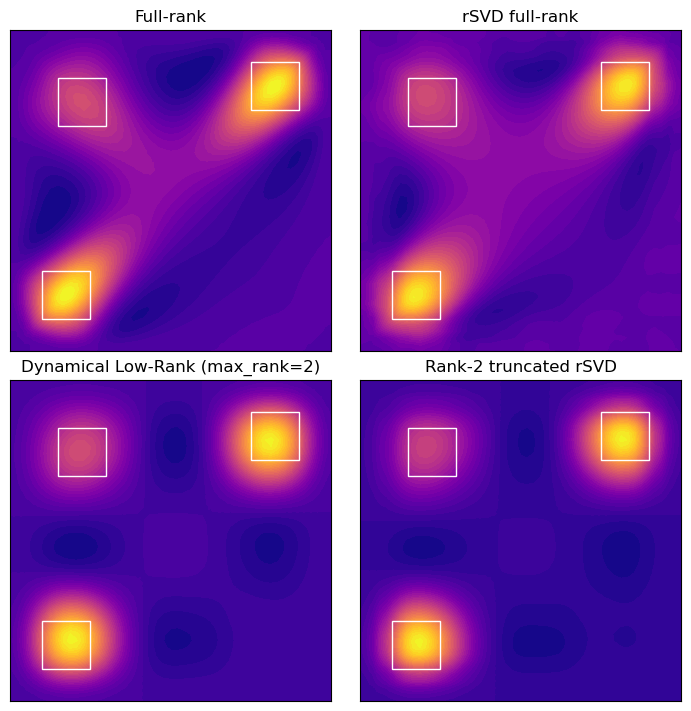

In [10]:
r = 2
lambda_ = 1e-4

# Full-rank solution
exact = ExactForwardOperator(p['V_h'])
f_fr = solve_explicit(exact, exact.get_weights(), p['y'], lambda_)

# Matrix-free rSVD
mfrsvd = MatrixFreeRSVD(p['V_h'])
mfrsvd.mf_rsvd(k=50)
w = get_approximate_W(mfrsvd.VkT.T, mfrsvd.M_dx)
x_hat = tikhonov_solver(mfrsvd, w, p['y'], lambda_=lambda_)
f_hat = Function(p['V_h'])
f_hat.vector()[:] = x_hat

# Truncated rSVD
index = SpaceIndexing(p['V_h'])
x_hat = f_hat.vector().get_local().copy()
X_hat = vec_to_matrix(x_hat, index)
U, S, Vt = np.linalg.svd(X_hat, full_matrices=False)
Ur, Sr, Vtr = U[:, :r], S[:r], Vt[:r, :]
X_r = Ur @ np.diag(Sr) @ Vtr
f_r = Function(p['V_h'])
f_r.vector()[:] = matrix_to_vec(X_r, index)

# Dynamical Low-Rank PCG
solver = DynamicalLowRankPCG(mfrsvd)
x_dlr = solver.solve(
    p['y'], w, preconditioner='ic',
    max_rank=r, lambda_=lambda_**2, verbose=False,
)
f_dlr = Function(p['V_h'])
f_dlr.vector()[:] = x_dlr

# Plot
f_list = [f_fr, f_hat, f_dlr, f_r]
titles = ['Full-rank', 'rSVD full-rank', f'Dynamical Low-Rank (max_rank={r})', f'Rank-{r} truncated rSVD']
params = problem_params['II']
plot_solutions(f_list, params, titles, figsize=(7, 7), nrows=2, ncols=2, cbar=False)